This notebook trains adversarial policies using Generative Adversarial Imitation Learning (GAIL) with Evolutionary Strategies to match expert behavior distributions across 16-prey and 32-prey conditions using separate discriminators for predator and prey. Real fish video data is used.

## GAIL - Video Predator-Prey

In [ ]:
# install this cell and then restart session after so that the new versions can be picked up
from google.colab import drive
drive.mount('/content/drive') # need to be mounted so that requirements is accessible

!pip install ema-pytorch geomloss[full] pykeops ultralytics deep-sort-realtime -q
!pip install -r /content/drive/MyDrive/Master-Thesis/requirements.txt -q
!pip install "numpy==2.0.2" --force-reinstall -q

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 552.2/552.2 kB 38.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.5/118.5 kB 13.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 85.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 135.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.0/66.0 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.0/83.0 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.4/319.4 kB 28.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 9.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 5.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 k

### Training

In [ ]:
# set working directory
from google.colab import drive
drive.mount('/content/drive')

import os, sys
os.chdir('/content/drive/MyDrive/Predator Prey Thesis')
sys.path.insert(0, '/content/drive/MyDrive/Predator Prey Thesis')

import numpy as np
print(np.__version__)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
2.0.2


In [ ]:
# set PyTorch memory allocation for GPU efficiency
import os
os.environ["PYTORCH_HIP_ALLOC_CONF"] = "expandable_segments:True"

In [ ]:
# imports
import torch
from pathlib import Path
from ema_pytorch import EMA
from datetime import datetime
import random, numpy as np, torch

# project specific helper modules
from utils.sim_utils import *
from utils.eval_utils import *
from utils.train_utils import *
from utils.couzin_utils import *
from utils.vec_sim_utils import *
from utils.encoder_utils import *
from utils.dataset_utils import pad_expert_tensors, pad_rollout_tensors

# sinkhorn
from geomloss import SamplesLoss

# maximum mean discrepency
from utils.mmd_loss import MMDLoss

from models.Generator import ModularPolicy
from models.Discriminator import Discriminator
from models.JointDiscriminator import JointDiscriminator

[KeOps] Compiling cuda jit compiler engine ... OK
[pyKeOps] Compiling nvrtc binder for python ... OK


In [ ]:
# training configuration
num_generations = 3000  # training generations
gamma = 0.999           # learning rate decay factor
pretrain=True           # use BC pretrain
performance_eval = 5    # evaluate performance every n generations
num_perturbations = 64  # perturbations for ES

### prey ###
lr_prey_policy = 2e-4   # learning rate prey policy
sigma_prey = 0.1        # prey ES exploration noise
prey_dis_balance_factor = 2 # prey discriminator steps per policy step
prey_noise = 0.005      # prey discriminator input noise
lr_prey_disc = 5e-4     # learning rate prey discriminator
lambda_gp_prey = 5      # prey gradient penalty factor
prey_update_mode = {"mode": "avoid", "lambda": 0.2} # prey update mode

### predator ###
lr_pred_policy = 1e-4   # learning rate predator policy
sigma_pred = 0.08       # pred scatter for ES (exploration)
pred_dis_balance_factor = 2 # pred discriminator steps per policy step
pred_noise = 0.005      # pred discriminator input noise
lr_pred_disc = 2e-4     # learning rate pred discriminator
lambda_gp_pred = 10     # pred gradient penalty factor
pred_update_mode = {"mode": "attack", "lambda": 0.1} # pred update mode

# environment settings
height = 2160
width = 2160
prey_speed = 10
pred_speed = 10
step_size = 1.0
max_turn = 0.314
pert_steps = 100 # perturbation steps
init_steps = 500 # initial steps
max_speed_norm = 25.0
env_settings = (height, width, prey_speed, pred_speed, step_size, max_turn, pert_steps, max_speed_norm)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# seeds for reproducibility
import random
import numpy as np
import torch
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [ ]:
# load expert tensors
window_len = 10
window_path = Path(f'/content/drive/MyDrive/Predator Prey Thesis/Data/1. Data Processing/Processed/video/expert_tensors/windows/{window_len} windows')

print(sorted(os.listdir(window_path)))
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

['pred_tensor_w10_n24.pt', 'pred_tensors_hl_w10_n3747.pkl', 'prey_tensor_w10_n24.pt', 'prey_tensors_hl_w10_n3747.pkl']


In [ ]:
# load paired predator and prey expert trajectory files
def load_expert_pairs(window_path, device=None):
    files = sorted(os.listdir(window_path))
    preds = [f for f in files if f.startswith('pred')]
    preys = [f for f in files if f.startswith('prey')]

    # match files by extracting key from filename
    key = lambda name: name.split('_', 1)[1] # strip the pred/prey prefix
    pred_map = {key(f): f for f in preds}
    prey_map = {key(f): f for f in preys}

    # ensure all files are paired
    unmatched = set(pred_map) ^ set(prey_map)
    if unmatched:
        raise RuntimeError(f"unpaired expert files: {sorted(unmatched)}")

    # load and concatenate
    pred_list, prey_list = [], []
    for k in sorted(pred_map):
        pd = torch.load(os.path.join(window_path, pred_map[k]), weights_only=False)
        py = torch.load(os.path.join(window_path, prey_map[k]), weights_only=False)
        assert pd.shape[0] == py.shape[0], f"{k}: {pd.shape[0]} pred vs {py.shape[0]} prey"
        pred_list.append(pd); prey_list.append(py)

    p = torch.cat(pred_list, 0).type(torch.float32)
    q = torch.cat(prey_list, 0).type(torch.float32)
    return (p.to(device), q.to(device)) if device else (p, q)

# load expert trajectories
exp_pred_tensor, exp_prey_tensor = load_expert_pairs(window_path, device)
print("Pred Tensor Shape:", exp_pred_tensor.shape)
print("Prey Tensor Shape:", exp_prey_tensor.shape)

Pred Tensor Shape: torch.Size([3771, 10, 1, 32, 6])
Prey Tensor Shape: torch.Size([3771, 10, 32, 32, 7])


In [ ]:
# filter by prey count
active_check = exp_prey_tensor[:, 0, :, 0, -2] # (N, 32): frame 0, all agents, neighbor 0, active flag
real_agent_mask = (active_check > 0) # (N, 32) boolean mask
n_prey_per_window = real_agent_mask.sum(dim=1) # (N,) count per window

# seperate into 16 and 32 prey datasets
cond16 = (n_prey_per_window == 16)
cond32 = (n_prey_per_window == 32)

exp_prey_tensor_16 = exp_prey_tensor[cond16]
exp_prey_tensor_32 = exp_prey_tensor[cond32]
exp_pred_tensor_16 = exp_pred_tensor[cond16]
exp_pred_tensor_32 = exp_pred_tensor[cond32]

print(f"16-prey windows: {cond16.sum().item()}  |  32-prey windows: {cond32.sum().item()}")

16-prey windows: 2978  |  32-prey windows: 793


In [ ]:
# load both init pools
init_pool_path_16 = Path('/content/drive/MyDrive/Predator Prey Thesis/Data/1. Data Processing/Processed/init_pool/init_pool_16prey.pt')
init_pool_16 = torch.load(init_pool_path_16).to(device)

init_pool_path_32 = Path('/content/drive/MyDrive/Predator Prey Thesis/Data/1. Data Processing/Processed/init_pool/init_pool_32prey.pt')
init_pool_32 = torch.load(init_pool_path_32).to(device)

In [ ]:
# load and freeze encoders

# initlize prey encoder and load weights from pretraining
prey_encoder = TransitionEncoder(features=6, embd_dim=32, z=32).to(device) # was 5

prey_encoder_path = Path('/content/drive/MyDrive/Predator Prey Thesis/models/trained_policies/Encoder/prey_encoder.pt')
prey_state = torch.load(prey_encoder_path, map_location=device)
prey_encoder.load_state_dict(prey_state)

# freeze prey encoder
for p in prey_encoder.parameters():
    p.requires_grad = False
prey_encoder.eval()
print("Prey Encoder loaded & frozen.\n")

# initialize predator encoder and load weights from pretraining
pred_encoder = TransitionEncoder(features=5, embd_dim=32, z=32).to(device) # was 4
pred_encoder_path = Path('/content/drive/MyDrive/Predator Prey Thesis/models/trained_policies/Encoder/pred_encoder.pt')
pred_state = torch.load(pred_encoder_path, map_location=device)
pred_encoder.load_state_dict(pred_state)

# freeze predator encoder
for p in pred_encoder.parameters():
    p.requires_grad = False
pred_encoder.eval()
print("Predator Encoder loaded & frozen.")

Prey Encoder loaded & frozen.

Predator Encoder loaded & frozen.


In [ ]:
# load pretrained policies (behavioral cloning)

# initialize prey policy and load pretrained weights
prey_policy = ModularPolicy(features=6).to(device) #was 5
prey_policy.set_parameters()

bc_prey_path = Path('/content/drive/MyDrive/Predator Prey Thesis/models/trained_policies/BC-Policy/bc_prey_policy.pt')

if pretrain:
    prey_policy.load_state_dict(torch.load(bc_prey_path, map_location=device))

# initialize EMA for prey policy
ema_prey = EMA(prey_policy, beta=0.9999, update_after_step=10, update_every=5, allow_different_devices=True)
print("Pretrained Prey Policy loaded.\n")

Pretrained Prey Policy loaded.



In [ ]:
# initialize predator policy and load pretrained weights
pred_policy = ModularPolicy(features=5).to(device) #was 4
pred_policy.set_parameters()

bc_pred_path = Path('/content/drive/MyDrive/Predator Prey Thesis/models/trained_policies/BC-Policy/bc_pred_policy.pt')


if pretrain:
    pred_policy.load_state_dict(torch.load(bc_pred_path, map_location=device))

# initialize EMA for predator policy
ema_pred = EMA(pred_policy, beta=0.9999, update_after_step=10, update_every=5, allow_different_devices=True)
print("Pretrained Predator Policy loaded.\n")

Pretrained Predator Policy loaded.



In [ ]:
# store initial parameter norms to prevent ES updates from drifting too far
theta_norm_ref_pred_pin = nn.utils.parameters_to_vector(pred_policy.pairwise.parameters()).norm().item()
theta_norm_ref_pred_an  = nn.utils.parameters_to_vector(pred_policy.attention.parameters()).norm().item()
theta_norm_ref_prey_pin = nn.utils.parameters_to_vector(prey_policy.pairwise.parameters()).norm().item()
theta_norm_ref_prey_an  = nn.utils.parameters_to_vector(prey_policy.attention.parameters()).norm().item()

In [ ]:
# initialize prey discriminator
prey_discriminator = Discriminator(encoder=prey_encoder, role="prey", z_dim=32).to(device)
prey_discriminator.set_parameters(init=True)
optim_disc_prey = torch.optim.RMSprop(prey_discriminator.parameters(), lr=lr_prey_disc, alpha=0.99, eps=1e-08)

# initialize predator discriminator
pred_discriminator = Discriminator(encoder=pred_encoder, role="predator", z_dim=32).to(device)
pred_discriminator.set_parameters(init=True)
optim_disc_pred = torch.optim.RMSprop(pred_discriminator.parameters(), lr=lr_pred_disc, alpha=0.99, eps=1e-08)

# initialize losses
prey_mmd_loss = MMDLoss(encoder=prey_encoder, role="prey").to(device)
pred_mmd_loss = MMDLoss(encoder=pred_encoder, role="predator").to(device)
sinkhorn_loss = SamplesLoss(loss="sinkhorn", backend="tensorized")

In [ ]:
# get expert distribution statistics for 32 prey
mmd_means, mmd_stds, sinkhorn_means, sinkhorn_stds = get_expert_values(
    exp_pred_tensor=exp_pred_tensor_32, exp_prey_tensor=exp_prey_tensor_32,
    prey_mmd_loss=prey_mmd_loss, pred_mmd_loss=pred_mmd_loss,
    prey_encoder=prey_encoder, pred_encoder=pred_encoder,
    sinkhorn_loss=sinkhorn_loss)

MMD_PREY, MMD_PRED = float(mmd_means[0]), float(mmd_means[1])
SNK_PREY, SNK_PRED = float(sinkhorn_means[0]), float(sinkhorn_means[1])

  0%|          | 0/500 [00:00<?, ?it/s]


Expert Prey MMD: 0.043908825397491455 ± 0.028609025709299084
Expert Prey Sinkhorn: 6.354277387436014e-05 ± 1.5319636518389432e-05

Expert Pred MMD: 0.2879375138282776 ± 0.153083096745626
Expert Pred Sinkhorn: 0.0002375885296642082 ± 5.827331916952394e-05


In [ ]:
# get expert distribution statistics for 16 prey
mmd_means16, mmd_stds16, sinkhorn_means16, sinkhorn_stds16 = get_expert_values(
    exp_pred_tensor=exp_pred_tensor_16, exp_prey_tensor=exp_prey_tensor_16,
    prey_mmd_loss=prey_mmd_loss, pred_mmd_loss=pred_mmd_loss,
    prey_encoder=prey_encoder, pred_encoder=pred_encoder,
    sinkhorn_loss=sinkhorn_loss)

MMD_PREY16, MMD_PRED16 = float(mmd_means16[0]), float(mmd_means16[1])
SNK_PREY16, SNK_PRED16 = float(sinkhorn_means16[0]), float(sinkhorn_means16[1])

  0%|          | 0/500 [00:00<?, ?it/s]


Expert Prey MMD: 0.00599702787399292 ± 0.00385467827027585
Expert Prey Sinkhorn: 2.2966309206822186e-06 ± 7.25675256652411e-07

Expert Pred MMD: 0.3580230162143707 ± 0.16876691235638647
Expert Pred Sinkhorn: 8.368322768365033e-05 ± 2.1093740795098183e-05


In [ ]:
# training setup
metrics_list = []
metrics_list_16 = []
policy_metrics_list = []
disc_metrics_list = []
gamma = 0.999

best_prey = float("inf")
best_pred = float("inf")
best_prey_policy_state = {k: v.detach().clone() for k, v in ema_prey.ema_model.state_dict().items()}
best_pred_policy_state = {k: v.detach().clone() for k, v in ema_pred.ema_model.state_dict().items()}

run_dir = Path('/content/drive/MyDrive/Predator Prey Thesis/Data/2. Training/VideoPredPrey - GAIL/stage1_seed42_32and16')
run_dir.mkdir(parents=True, exist_ok=True)

# training Loop
for gen in range(num_generations):

    # select condition: 50/50 between 16-prey and 32-prey
    n_prey = random.choice([16, 32])
    if n_prey == 16:
        cond_init_pool = init_pool_16
        cond_exp_pred_tensor = exp_pred_tensor_16
        cond_exp_prey_tensor = exp_prey_tensor_16
    else:
        cond_init_pool = init_pool_32
        cond_exp_pred_tensor = exp_pred_tensor_32
        cond_exp_prey_tensor = exp_prey_tensor_32

    # use EMA models for rollouts
    rollout_prey_policy = ema_prey.ema_model.to(device)
    rollout_pred_policy = ema_pred.ema_model.to(device)

    # generate rollouts with current policies
    gen_pred_tensor, gen_prey_tensor = run_env_vectorized(prey_policy=rollout_prey_policy, pred_policy=rollout_pred_policy,
                                                          n_prey=n_prey, n_pred=1, max_steps=100, init_pool=cond_init_pool,
                                                          area_width=width, area_height=height,
                                                          prey_speed=prey_speed, pred_speed=pred_speed,
                                                          step_size=step_size, max_turn=max_turn,
                                                          max_speed_norm=max_speed_norm)

    # pad to max_prey=32 format (adds active-mask column)
    gen_pred_tensor, gen_prey_tensor = pad_rollout_tensors(gen_pred_tensor, gen_prey_tensor, max_prey=32)

    # update discriminators
    for i in range(pred_dis_balance_factor):
        expert_pred_batch, _ = sample_data(cond_exp_pred_tensor, batch_size=20, window_len=10)
        generative_pred_batch, _ = sample_data(gen_pred_tensor, batch_size=20, window_len=10)
        expert_pred_batch = expert_pred_batch.to(device)
        generative_pred_batch = generative_pred_batch.to(device)
        dis_metric_pred = pred_discriminator.update(expert_pred_batch, generative_pred_batch, optim_disc_pred,
                                                    lambda_gp_pred, noise=pred_noise, generation=gen, num_generations=num_generations)

    for i in range(prey_dis_balance_factor):
        expert_prey_batch, _ = sample_data(cond_exp_prey_tensor, batch_size=10, window_len=10)
        generative_prey_batch, _ = sample_data(gen_prey_tensor, batch_size=10, window_len=10)
        expert_prey_batch = expert_prey_batch.to(device)
        generative_prey_batch = generative_prey_batch.to(device)
        dis_metric_prey = prey_discriminator.update(expert_prey_batch, generative_prey_batch, optim_disc_prey,
                                                    lambda_gp_prey, noise=prey_noise, generation=gen, num_generations=num_generations)

        disc_metrics_list.append((dis_metric_prey, dis_metric_pred))


    # sample initial positions for ES
    init_pos = init_positions(cond_init_pool, batch=num_perturbations, mode="dual",
                          area_width=width, area_height=height)

    # optimize pred PIN with ES
    pin_pred_metrics = optimize_es(pred_policy=pred_policy, prey_policy=prey_policy,
                               role="pred", module="pairwise", mode=pred_update_mode,
                               discriminator=pred_discriminator, lr=lr_pred_policy, sigma=sigma_pred,
                               num_perturbations=num_perturbations, init_pos=init_pos,
                               settings_batch_env=env_settings, n_prey=n_prey,
                               theta_norm_ref=theta_norm_ref_pred_pin)

    # optimize pred AN with ES
    an_pred_metrics  = optimize_es(pred_policy=pred_policy, prey_policy=prey_policy,
                               role="pred", module="attention", mode=pred_update_mode,
                               discriminator=pred_discriminator, lr=lr_pred_policy, sigma=sigma_pred,
                               num_perturbations=num_perturbations, init_pos=init_pos,
                               settings_batch_env=env_settings, n_prey=n_prey,
                               theta_norm_ref=theta_norm_ref_pred_an)
    ema_pred.update()

    # optimize prey PIN with ES
    pin_prey_metrics = optimize_es(pred_policy=pred_policy, prey_policy=prey_policy,
                               role="prey", module="pairwise", mode=prey_update_mode,
                               discriminator=prey_discriminator, lr=lr_prey_policy, sigma=sigma_prey,
                               num_perturbations=num_perturbations, init_pos=init_pos,
                               settings_batch_env=env_settings, n_prey=n_prey,
                               theta_norm_ref=theta_norm_ref_prey_pin)

    # optimize prey AN with ES
    an_prey_metrics  = optimize_es(pred_policy=pred_policy, prey_policy=prey_policy,
                               role="prey", module="attention", mode=prey_update_mode,
                               discriminator=prey_discriminator, lr=lr_prey_policy, sigma=sigma_prey,
                               num_perturbations=num_perturbations, init_pos=init_pos,
                               settings_batch_env=env_settings, n_prey=n_prey,
                               theta_norm_ref=theta_norm_ref_prey_an)
    ema_prey.update()

    # memory clean up
    import gc
    gc.collect()
    torch.cuda.empty_cache()

    # append metrics
    policy_metrics_list.append({"predator": (pin_pred_metrics, an_pred_metrics), "prey": (pin_prey_metrics, an_prey_metrics), "n_prey": n_prey})

    # decay learning rates and exploration noise
    lr_pred_policy *= gamma
    lr_prey_policy *= gamma
    sigma_pred *= gamma
    sigma_prey *= gamma

    # evalute current policies
    if gen % performance_eval == 0:
        m32 = calculate_metrics(pred_policy=pred_policy, prey_policy=prey_policy,
                                prey_encoder=prey_encoder, pred_encoder=pred_encoder,
                                exp_prey_tensor=exp_prey_tensor_32, exp_pred_tensor=exp_pred_tensor_32,
                                prey_mmd_loss=prey_mmd_loss, pred_mmd_loss=pred_mmd_loss,
                                sinkhorn_loss=sinkhorn_loss,
                                init_pool=init_pool_32, n_prey=32, env_settings=env_settings, device="cuda")
        m16 = calculate_metrics(pred_policy=pred_policy, prey_policy=prey_policy,
                                prey_encoder=prey_encoder, pred_encoder=pred_encoder,
                                exp_prey_tensor=exp_prey_tensor_16, exp_pred_tensor=exp_pred_tensor_16,
                                prey_mmd_loss=prey_mmd_loss, pred_mmd_loss=pred_mmd_loss,
                                sinkhorn_loss=sinkhorn_loss,
                                init_pool=init_pool_16, n_prey=16, env_settings=env_settings, device="cuda")

        metrics = m32
        metrics_list.append(m32)
        metrics_list_16.append({"gen": gen, **m16})

        current_prey_state = ema_prey.ema_model.state_dict()
        current_pred_state = ema_pred.ema_model.state_dict()

        # selection on 32 only
        prey_score = m32["mmd_prey_mean"]/MMD_PREY + m32["sinkhorn_prey_mean"]/SNK_PREY
        pred_score = m32["mmd_pred_mean"]/MMD_PRED + m32["sinkhorn_pred_mean"]/SNK_PRED

        if prey_score < best_prey:
            best_prey = prey_score
            best_prey_policy_state = {k: v.detach().clone() for k, v in current_prey_state.items()}
            print(f"New best PREY {prey_score:.2f}x  "
                  f"(mmd {m32['mmd_prey_mean']/MMD_PREY:.1f}x, snk {m32['sinkhorn_prey_mean']/SNK_PREY:.1f}x)\n")
        if pred_score < best_pred:
            best_pred = pred_score
            best_pred_policy_state = {k: v.detach().clone() for k, v in current_pred_state.items()}
            print(f"New best PRED {pred_score:.2f}x  "
                  f"(mmd {m32['mmd_pred_mean']/MMD_PRED:.1f}x, snk {m32['sinkhorn_pred_mean']/SNK_PRED:.1f}x)\n")

        print(f"[16-PREY] prey {m16['mmd_prey_mean']/MMD_PREY16:.2f}x mmd, "
              f"{m16['sinkhorn_prey_mean']/SNK_PREY16:.2f}x snk | "
              f"pred {m16['mmd_pred_mean']/MMD_PRED16:.2f}x mmd, "
              f"{m16['sinkhorn_pred_mean']/SNK_PRED16:.2f}x snk")

    print(f"Generation {gen+1}  [condition: n_prey={n_prey}]")
    print(f"[PREY] PIN Network:   {pin_prey_metrics}")
    print(f"[PREY] AN Network:    {an_prey_metrics}")
    print(f"[PREY] Discriminator: {dis_metric_prey}")
    print(f"[PREY] Score Diff: {abs(dis_metric_prey['expert_score_mean'] - dis_metric_prey['policy_score_mean'])}")
    if gen % performance_eval == 0:
        print(f"[PREY] MMD: {metrics['mmd_prey_mean']:.4f} ± {metrics['mmd_prey_std']:.4f} | "
              f"Sinkhorn: {metrics['sinkhorn_prey_mean']:.4f} ± {metrics['sinkhorn_prey_std']:.4f}")
    print("--------------------------------")
    print(f"[PRED] PIN Network:   {pin_pred_metrics}")
    print(f"[PRED] AN Network:    {an_pred_metrics}")
    print(f"[PRED] Discriminator: {dis_metric_pred}")
    print(f"[PRED] Score Diff: {abs(dis_metric_pred['expert_score_mean'] - dis_metric_pred['policy_score_mean'])}")
    if gen % performance_eval == 0:
        print(f"[PRED] MMD: {metrics['mmd_pred_mean']:.4f} ± {metrics['mmd_pred_std']:.4f} | "
              f"Sinkhorn: {metrics['sinkhorn_pred_mean']:.4f} ± {metrics['sinkhorn_pred_std']:.4f}\n")

    # save checkpoint every 50 generations
    if (gen + 1) % 50 == 0:
        torch.save({
            "gen": gen,
            "prey_policy": prey_policy.state_dict(), "pred_policy": pred_policy.state_dict(),
            "ema_prey": ema_prey.state_dict(), "ema_pred": ema_pred.state_dict(),
            "prey_disc": prey_discriminator.state_dict(), "pred_disc": pred_discriminator.state_dict(),
            "optim_disc_prey": optim_disc_prey.state_dict(), "optim_disc_pred": optim_disc_pred.state_dict(),
            "best_prey_policy_state": best_prey_policy_state, "best_pred_policy_state": best_pred_policy_state,
            "best_prey": best_prey, "best_pred": best_pred,
            "lr_pred_policy": lr_pred_policy, "lr_prey_policy": lr_prey_policy,
            "sigma_pred": sigma_pred, "sigma_prey": sigma_prey,
            "metrics_list": metrics_list, "metrics_list_16": metrics_list_16,
            "policy_metrics_list": policy_metrics_list, "disc_metrics_list": disc_metrics_list,
        }, run_dir / "ckpt_latest.pt")

# load best policies
prey_policy.load_state_dict(best_prey_policy_state, strict=True)
pred_policy.load_state_dict(best_pred_policy_state, strict=True)

Streaming output truncated to the last 5000 lines.
Generation 2538  [condition: n_prey=32]
[PREY] PIN Network:   {'diff_mean': 0.000625, 'diff_std': 0.010299, 'delta_norm': 0.413966, 'clip_ratio': 0.247885, 'delta_raw_norm': 1.669993, 'max_delta_norm': 0.413966, 'avoid/attack reward': 0.431422}
[PREY] AN Network:    {'diff_mean': -0.000375, 'diff_std': 0.011122, 'delta_norm': 0.492702, 'clip_ratio': 0.296265, 'delta_raw_norm': 1.663044, 'max_delta_norm': 0.492702, 'avoid/attack reward': 0.434143}
[PREY] Discriminator: {'dis_loss': -0.0186, 'dis_loss_gp': -0.0175, 'grad_penalty': 0.0002, 'expert_score_mean': 0.0467, 'policy_score_mean': 0.028}
[PREY] Score Diff: 0.018699999999999998
--------------------------------
[PRED] PIN Network:   {'diff_mean': 0.002373, 'diff_std': 0.052304, 'delta_norm': 0.243612, 'clip_ratio': 0.185945, 'delta_raw_norm': 1.310132, 'max_delta_norm': 0.243612, 'avoid/attack reward': -0.138723}
[PRED] AN Network:    {'diff_mean': 0.00307, 'diff_std': 0.055708, 'de

<All keys matched successfully>

In [ ]:
# save trained policies
run_dir = Path('/content/drive/MyDrive/Predator Prey Thesis/Data/2. Training/VideoPredPrey - GAIL/stage1_seed42_32and16')
run_dir.mkdir(parents=True, exist_ok=True)

prey_path = run_dir / "prey_policy_stage1.pth"
torch.save(prey_policy.state_dict(), prey_path)

pred_path = run_dir / "pred_policy_stage1.pth"
torch.save(pred_policy.state_dict(), pred_path)

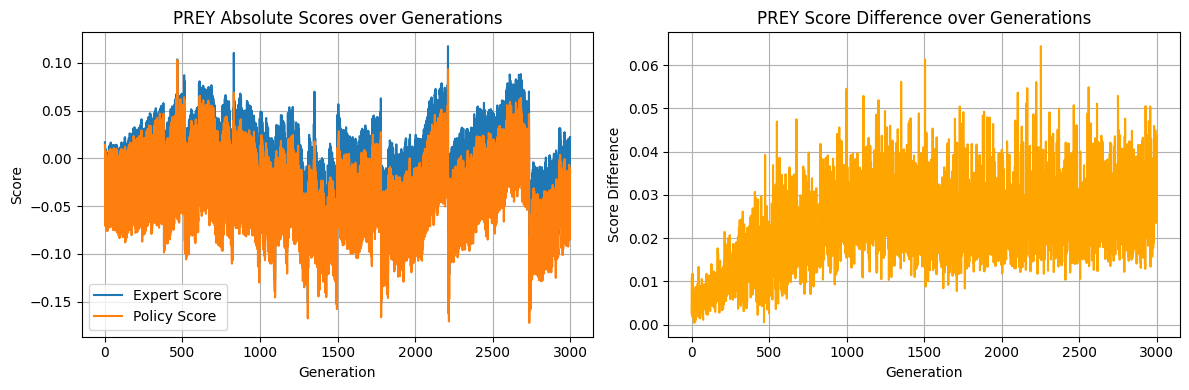

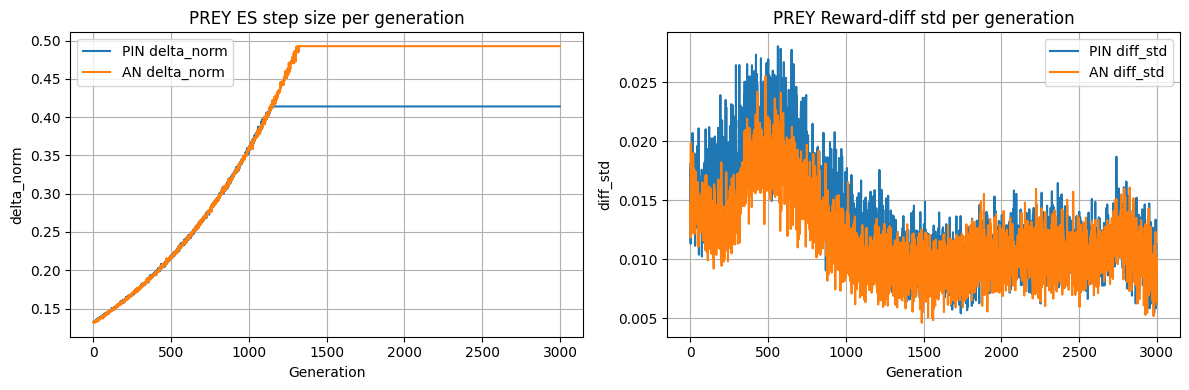

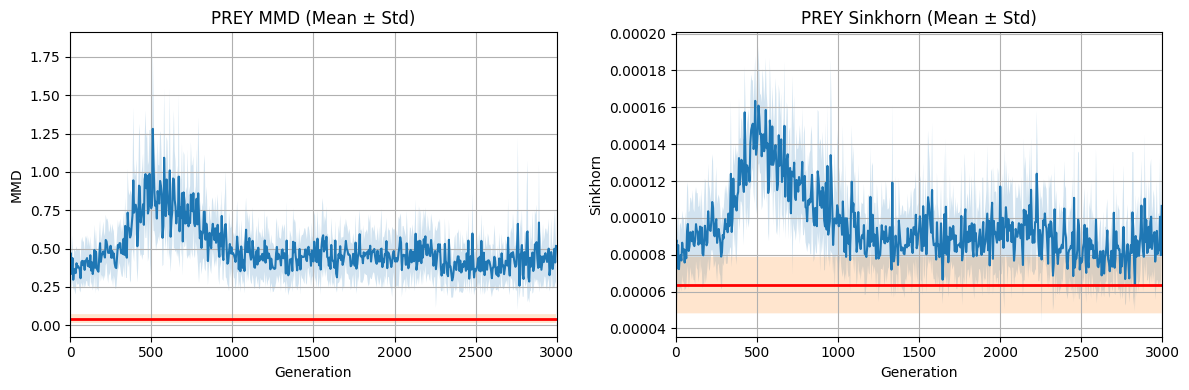

In [ ]:
# plot trianing metrics

%matplotlib inline
# plot training and evaluation metrics for prey
plot_train_metrics(disc_metrics_list, prey_dis_balance_factor, role="prey", save_dir=run_dir)
plot_es_metrics(policy_metrics_list, role="prey", save_dir=run_dir)
plot_eval_metrics(metrics_list, role="prey",
                  mmd_means=mmd_means, mmd_stds=mmd_stds,
                  sinkhorn_means=sinkhorn_means, sinkhorn_stds=sinkhorn_stds,
                  max_steps=num_generations, save_dir=run_dir)

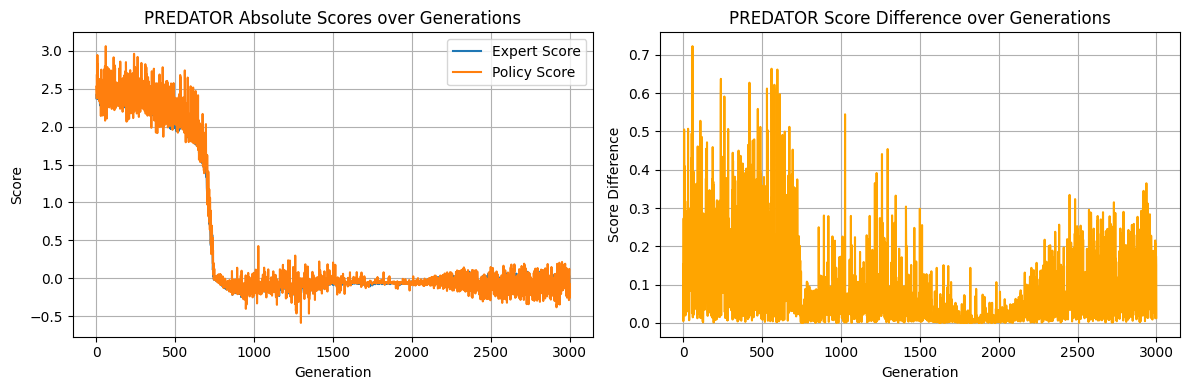

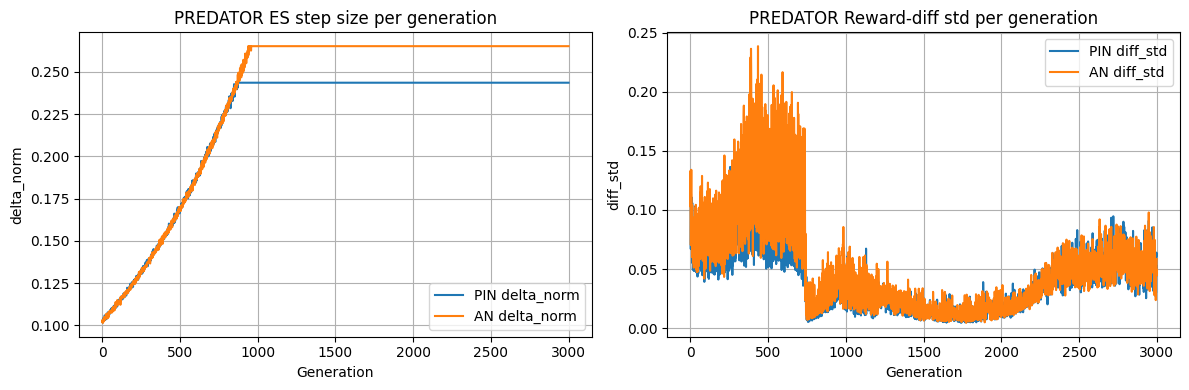

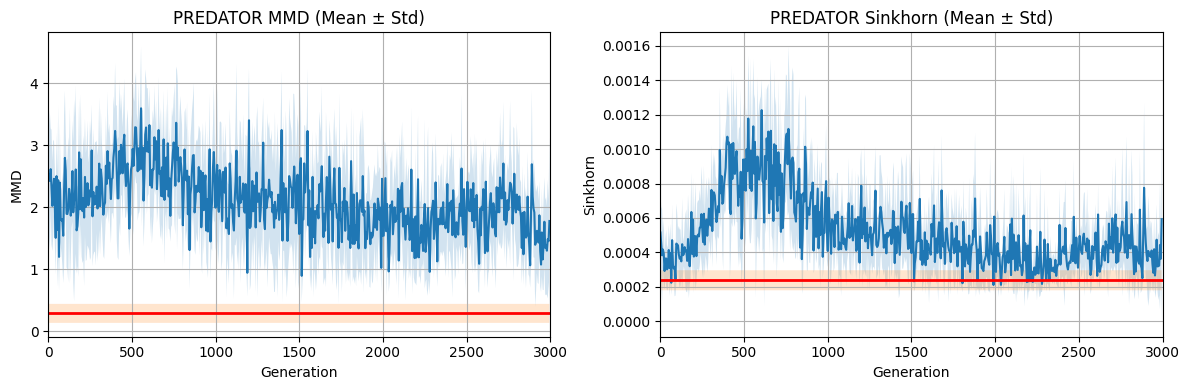

In [ ]:
%matplotlib inline
# plot training and evaluation metrics for predator
plot_train_metrics(disc_metrics_list, pred_dis_balance_factor, role="predator", save_dir=run_dir)
plot_es_metrics(policy_metrics_list, role="predator", save_dir=run_dir)
plot_eval_metrics(metrics_list, role="predator",
                  mmd_means=mmd_means, mmd_stds=mmd_stds,
                  sinkhorn_means=sinkhorn_means, sinkhorn_stds=sinkhorn_stds,
                  max_steps=num_generations, save_dir=run_dir)

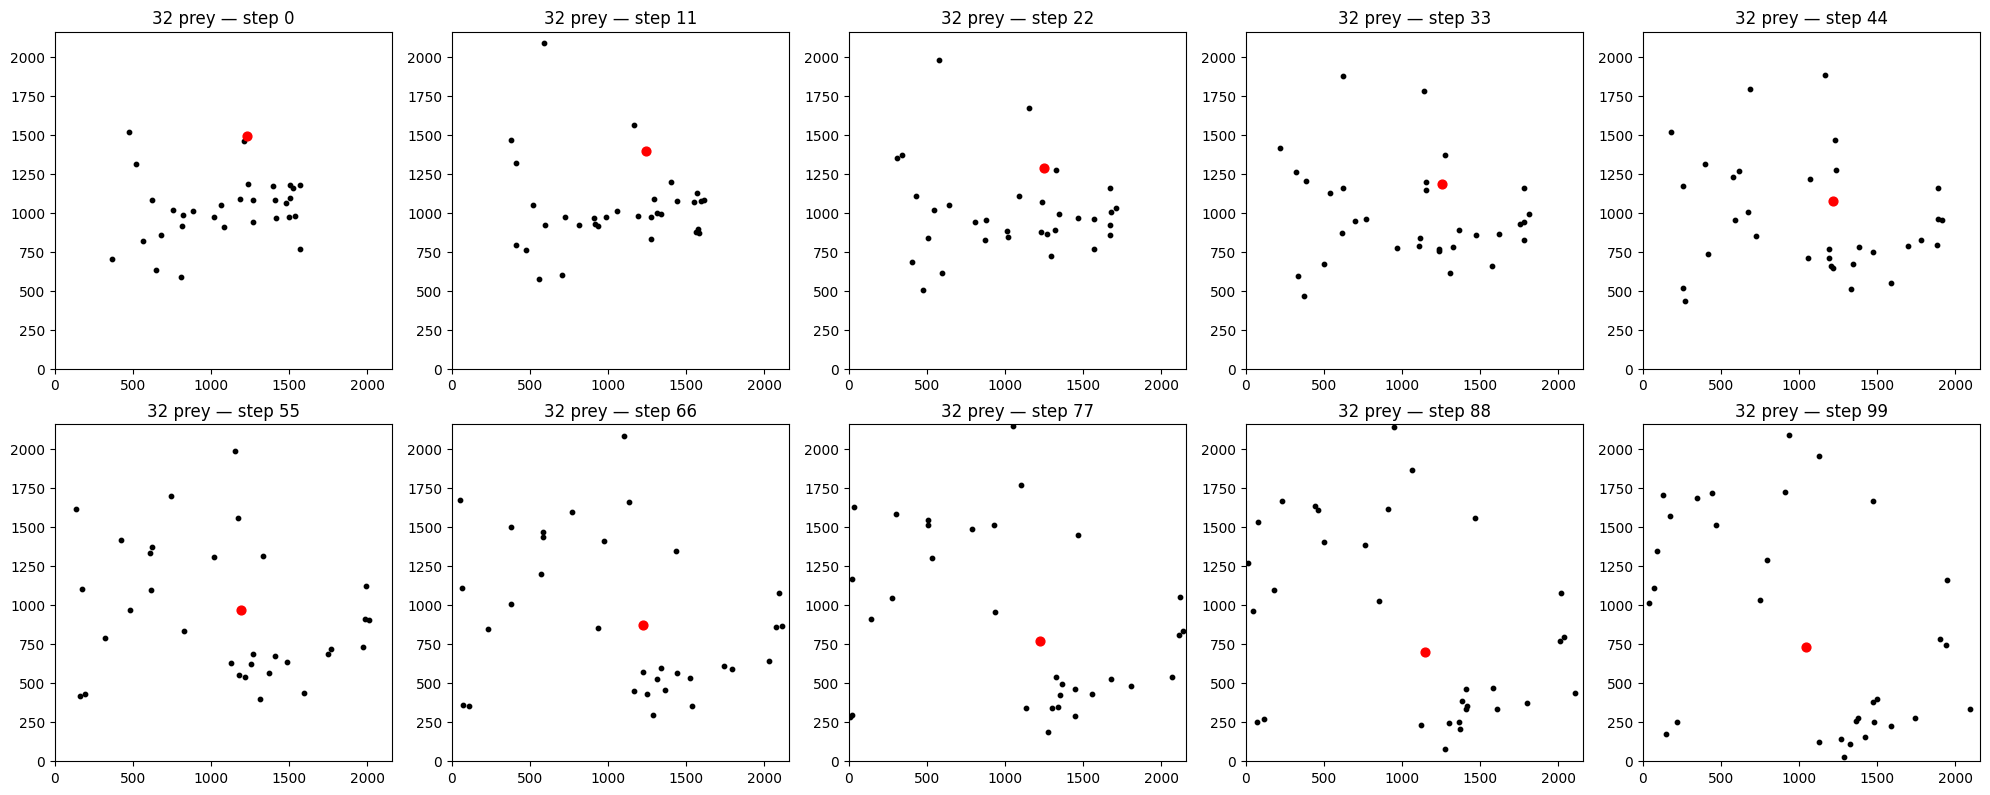

32-prey video: True 198962


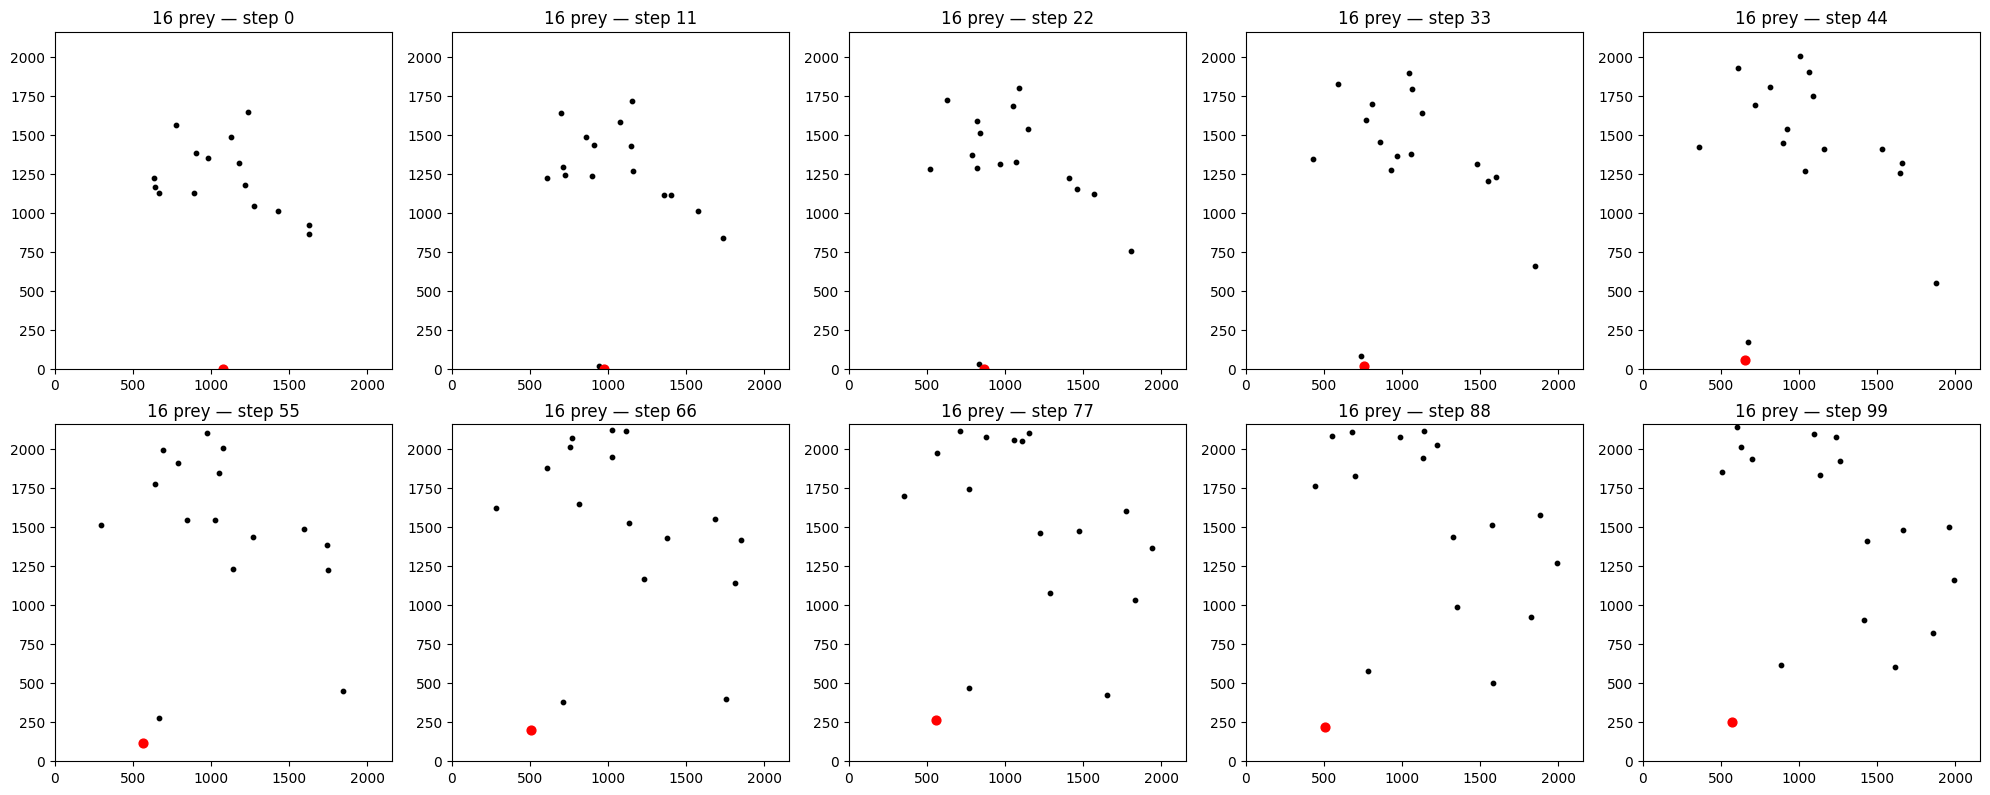

16-prey video: True 127400


In [ ]:
# visualize stage 1 policies

%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np

# final evaluation metrics
for tag, ip, ep, epy, n in [("32", init_pool_32, exp_pred_tensor_32, exp_prey_tensor_32, 32),
                            ("16", init_pool_16, exp_pred_tensor_16, exp_prey_tensor_16, 16)]:
    fm = calculate_metrics(pred_policy=pred_policy, prey_policy=prey_policy,
                           prey_encoder=prey_encoder, pred_encoder=pred_encoder,
                           exp_prey_tensor=epy, exp_pred_tensor=ep,
                           prey_mmd_loss=prey_mmd_loss, pred_mmd_loss=pred_mmd_loss,
                           sinkhorn_loss=sinkhorn_loss, init_pool=ip, n_prey=n,
                           env_settings=env_settings, device="cuda", n_episodes=10)

# generate and save rollout visualization
def visualise(n_prey_vis, init_pool_vis, tag):
    _, _, gm = run_env_simulation(visualization='off',
                                  prey_policy=prey_policy, pred_policy=pred_policy,
                                  n_prey=n_prey_vis, n_pred=1, max_steps=100,
                                  pred_speed=pred_speed, prey_speed=prey_speed,
                                  area_width=width, area_height=height,
                                  max_turn=max_turn, step_size=step_size,
                                  max_speed_norm=max_speed_norm, init_pool=init_pool_vis)
    steps, _ = gm

    # static frames
    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    for ax, s in zip(axes.flat, np.linspace(0, len(steps) - 1, 10, dtype=int)):
        m = steps[s]
        xs, ys = m["xs"] * width, m["ys"] * height
        ax.scatter(xs[1:], ys[1:], c='black', s=10)
        ax.scatter(xs[0],  ys[0],  c='red',   s=40)
        ax.set_xlim(0, width); ax.set_ylim(0, height)
        ax.set_aspect('equal'); ax.set_title(f"{tag} prey — step {s}")
    plt.tight_layout()
    plt.show()

    # animation
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_xlim(0, width); ax.set_ylim(0, height); ax.set_aspect('equal')
    pred_scat = ax.scatter([], [], c='red',  s=60, label='Predator')
    prey_scat = ax.scatter([], [], c='blue', s=20, label='Prey')
    ax.legend(loc='upper right')

    def update(frame):
        m = steps[frame]
        xs = np.asarray(m["xs"]) * width
        ys = np.asarray(m["ys"]) * height
        pred_scat.set_offsets([[xs[0], ys[0]]])
        prey_scat.set_offsets(np.stack([xs[1:], ys[1:]], axis=1))
        ax.set_title(f"{tag} prey — step {frame}")
        return pred_scat, prey_scat

    ani = animation.FuncAnimation(fig, update, frames=len(steps), interval=1000/15, blit=True)
    out_path = run_dir / f"rollout_stage1_{tag}prey.mp4"
    ani.save(str(out_path), writer=animation.FFMpegWriter(fps=15, bitrate=1800))
    plt.close(fig)
    print(f"{tag}-prey video:", out_path.exists(), out_path.stat().st_size)
    return gm

sim_32 = visualise(32, init_pool_32, "32")
sim_16 = visualise(16, init_pool_16, "16")